Inputs shape: (36, 4)
Outputs shape: (36,)
First 20 rows of raw data:
    hype-para--1  hype-para-2  hype-para-3  hype-para-4  opt-place-score  source
27      0.577766     0.428772     0.425826     0.249007        -4.025542    file
30      0.469388     0.448980     0.469388     0.204082        -4.620232  week-1
31      0.515152     0.484848     0.363636     0.181819        -4.939960  week-2
32      0.515152     0.484848     0.363636     0.181819        -5.313374  week-3
24      0.326076     0.472367     0.453192     0.105887        -6.702089    file
34      0.343612     0.592249     0.651353     0.444513        -7.221570  week-5
35      0.445393     0.174795     0.339088     0.116347        -7.600577  week-6
23      0.282138     0.505987     0.530531     0.096302        -7.966775    file
4       0.124871     0.129770     0.384400     0.287076       -10.069633    file
21      0.170347     0.756959     0.276520     0.531231       -11.565742    file
2       0.250946     0.033693     0.145

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


Epoch 1/500, Train Loss: 0.890972, Val Loss: 1.457389
Epoch 50/500, Train Loss: 0.174378, Val Loss: 0.431382
Epoch 100/500, Train Loss: 0.017789, Val Loss: 0.065688
Epoch 150/500, Train Loss: 0.001863, Val Loss: 0.043386
Epoch 200/500, Train Loss: 0.000262, Val Loss: 0.042081
Epoch 250/500, Train Loss: 0.000039, Val Loss: 0.041603
Epoch 300/500, Train Loss: 0.000006, Val Loss: 0.041404
Epoch 350/500, Train Loss: 0.000001, Val Loss: 0.041242
Epoch 400/500, Train Loss: 0.000000, Val Loss: 0.041164
Early stopping at epoch 416, best val_loss=0.041209


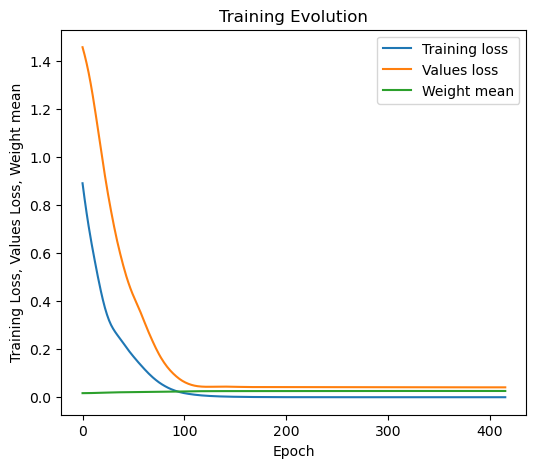

Using 4 dimensions, grid size per axis: 200, downsample: True, stride: 8
Points before downsampling: 1600000000
Points after downsampling: 390625
Final grid shape: (390625, 4)
Filtered 7813 candidates using filter_strategy='boundary'
Predictions range (scaled): -0.7200 to 1.3805
Inverse-transforming predictions to raw units
Predictions range (raw): -20.9670 to -5.1565
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.52889297, 0.37527963, 0.46511385, 0.44798294]), 'score': 0.2284161699273488, 'dim': 4, 'predicted_y': -5.1565075}
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.52889297, 0.37527963, 0.46511385, 0.44798294]), 'score': 0.2284161699273488, 'dim': 4, 'predicted_y': -5.1565075}
{'method': 'PI', 'xi': 0.3, 'kappa': None, 'x': array([0.48565189, 0.41586626, 0.50648783, 0.49178123]), 'score': 0.029003219622761922, 'dim': 4, 'predicted_y': -5.651478}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.48565189, 0.41586

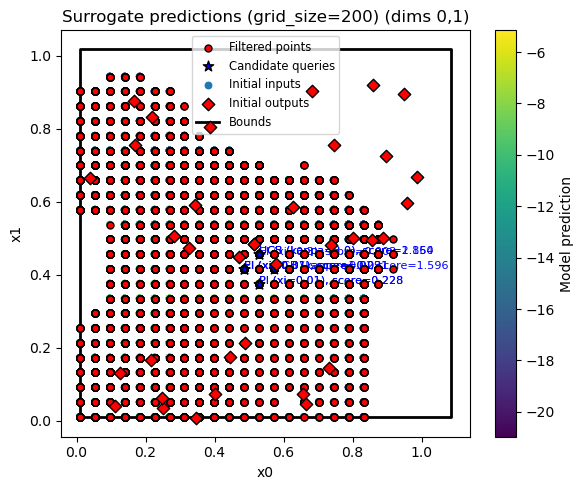

<Figure size 600x500 with 0 Axes>

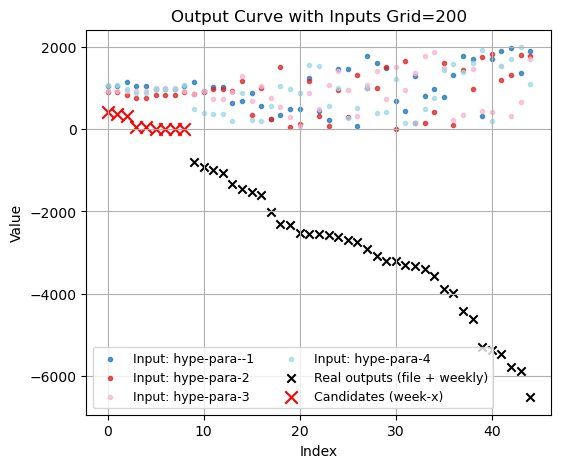

Saved dataframe to: results/run_2025-12-13 15-55-04/df_grid_200_stride8_gp_max_raw_lr0.001_ep600.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.52889297, 0.45645289, 0.46511385, 0.53557953]), 'score': 2.1539245614838256, 'dim': 4, 'predicted_y': -5.9685507}
    hype-para--1  hype-para-2  hype-para-3  hype-para-4  opt-place-score  source  opt-place-score-scaled
0       0.528893     0.456453     0.465114     0.535580         2.153925  week-x               10.000000
1       0.528893     0.456453     0.465114     0.535580         1.860160  week-x                8.636143
2       0.572134     0.415866     0.465114     0.491781         1.595983  week-x                7.409651
3       0.528893     0.375280     0.465114     0.447983         0.228416  week-x                1.060465
4       0.528893     0.375280     0.465114     0.447983         0.228416  week-x                1.060465
5       0.485652     0.415866     0.506488     0.491781         0.031011  week-x 

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))